# Secure Fruit Classification Model

> **L'objectif recherché est d'aboutir à l'entrainement d'un modéle de classification durci, donc résistant aux attaques de type adversariales**

# Reference Standard Model

## Installation & Importations

In [22]:
#Importations
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
import pickle
import numpy as np
import time
import glob
import copy

#Torch libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

#Data handling and metrics libraries
from PIL import Image, ImageFilter
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

#Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print('All modules are well imported and loaded')

All modules are well imported and loaded


## Parameters use

In [2]:
SEED         = 42
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 2

# Phase A
EPOCHS_BASELINE    = 15
LR_FROZEN          = 1e-3
LR_FINETUNE        = 1e-4
WEIGHT_DECAY       = 1e-4

# Phase B — attaques
FGSM_EPSILONS = [0.01, 0.03, 0.05, 0.1, 0.15]
PGD_EPSILONS  = [0.01, 0.03, 0.05, 0.1]
PGD_ALPHA     = 0.007
PGD_STEPS     = 10
POISON_FRACS  = [0.05, 0.1, 0.2, 0.3]

# Phase C — durcissement
EPOCHS_HARDEN  = 10
ADV_EPSILON    = 0.03
ADV_ALPHA      = 0.007
ADV_STEPS      = 7
ADV_RATIO      = 0.5

DATA_DIR      = "/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images"
MY_IMAGES_DIR = "/kaggle/input/datasets/hacerone/advrsvegetable"
OUTPUT_DIR    = "/kaggle/working"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## Loading & Preprocessing

In [3]:
# %% — Données
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    normalize,
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    normalize,
])

train_dataset = ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = ImageFolder(os.path.join(DATA_DIR, "validation"), transform=eval_transform)
test_dataset  = ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes (15): ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Train: 15000 | Val: 3000 | Test: 3000


## Functions (Adversarial attacks, Evaluation, Model Construction)

In [4]:
# %% — Utilitaires réutilisés dans les 3 phases

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
denorm = lambda t: (t.cpu().squeeze(0) * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

def fgsm_attack(mdl, images, labels, epsilon):
    inp = images.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(mdl(inp), labels)
    mdl.zero_grad(); loss.backward()
    return (inp + epsilon * inp.grad.sign()).detach()

def pgd_attack(mdl, images, labels, epsilon, alpha, steps):
    adv = images.clone().detach() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    for _ in range(steps):
        adv.requires_grad_(True)
        loss = F.cross_entropy(mdl(adv), labels)
        mdl.zero_grad(); loss.backward()
        adv = (adv.detach() + alpha * adv.grad.sign())
        adv = images + torch.clamp(adv - images, -epsilon, epsilon)
    return adv.detach()

def evaluate_clean(mdl, loader):
    mdl.eval()
    preds_all, labels_all, loss_sum, total = [], [], 0.0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = mdl(imgs)
            loss_sum += F.cross_entropy(out, lbls, reduction='sum').item()
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(lbls.cpu().numpy())
            total += lbls.size(0)
    preds_all, labels_all = np.array(preds_all), np.array(labels_all)
    acc = 100.0 * (preds_all == labels_all).sum() / len(labels_all)
    prec, rec, f1, _ = precision_recall_fscore_support(labels_all, preds_all, average='weighted')
    return {"accuracy": acc, "loss": loss_sum/total, "precision": prec,
            "recall": rec, "f1": f1, "preds": preds_all, "labels": labels_all}

def evaluate_attack(mdl, loader, attack_fn):
    mdl.eval()
    correct, total = 0, 0
    preds_all, labels_all = [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        adv = attack_fn(mdl, imgs, lbls)
        with torch.no_grad():
            p = mdl(adv).argmax(1)
        correct += p.eq(lbls).sum().item()
        total += lbls.size(0)
        preds_all.extend(p.cpu().numpy()); labels_all.extend(lbls.cpu().numpy())
    acc = 100.0 * correct / total
    _, _, f1, _ = precision_recall_fscore_support(labels_all, preds_all, average='weighted', zero_division=0)
    return {"accuracy": acc, "f1": f1}

def build_model():
    mdl = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_f = mdl.classifier[1].in_features
    mdl.classifier = nn.Sequential(
        nn.Dropout(0.3, inplace=True), nn.Linear(in_f, 256),
        nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, NUM_CLASSES))
    return mdl.to(DEVICE)

## Model Construction

In [6]:
# %% — Construction et entraînement
print(" PHASE A : ENTRAÎNEMENT DU MODÈLE DE BASE")

baseline = build_model()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
hist_A = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_A = 0.0

 PHASE A : ENTRAÎNEMENT DU MODÈLE DE BASE
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


## Initial Training

In [7]:
# ── A.1 : backbone gelé ──
print("\n A.1 — Feature extraction (backbone gelé)")
for p in baseline.features.parameters(): p.requires_grad = False

opt = optim.Adam(filter(lambda p: p.requires_grad, baseline.parameters()), lr=LR_FROZEN, weight_decay=WEIGHT_DECAY)
sched = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
P1 = EPOCHS_BASELINE // 2

for epoch in range(1, P1 + 1):
    baseline.train()
    rloss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        opt.zero_grad()
        out = baseline(imgs); loss = criterion(out, lbls)
        loss.backward(); opt.step()
        rloss += loss.item() * imgs.size(0)
        correct += out.argmax(1).eq(lbls).sum().item(); total += lbls.size(0)
    sched.step()
    tl, ta = rloss/total, 100.*correct/total

    res = evaluate_clean(baseline, val_loader)
    vl, va = res["loss"], res["accuracy"]
    hist_A["train_loss"].append(tl); hist_A["train_acc"].append(ta)
    hist_A["val_loss"].append(vl);   hist_A["val_acc"].append(va)

    print(f"  Epoch [{epoch}/{P1}] Train: {tl:.4f}/{ta:.2f}% | Val: {vl:.4f}/{va:.2f}%")
    if va > best_val_acc_A:
        best_val_acc_A = va
        torch.save(baseline.state_dict(), os.path.join(OUTPUT_DIR, "_best_A.pth"))


 A.1 — Feature extraction (backbone gelé)
  Epoch [1/7] Train: 0.8858/92.24% | Val: 0.1794/98.67%
  Epoch [2/7] Train: 0.7312/97.32% | Val: 0.1482/99.17%
  Epoch [3/7] Train: 0.7081/97.86% | Val: 0.1368/99.20%
  Epoch [4/7] Train: 0.7054/97.91% | Val: 0.1275/99.17%
  Epoch [5/7] Train: 0.6964/98.18% | Val: 0.1182/99.40%
  Epoch [6/7] Train: 0.6839/98.66% | Val: 0.1191/99.53%
  Epoch [7/7] Train: 0.6751/98.75% | Val: 0.1213/99.53%


## Fine Tuning

In [10]:
# ── A.2 : fine-tuning ──
print(f"\n A.2 — Fine-tuning complet")
for p in baseline.features.parameters(): p.requires_grad = True

opt = optim.Adam(baseline.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)
P2 = EPOCHS_BASELINE - P1
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=P2)

for epoch in range(1, P2 + 1):
    t0 = time.time()
    baseline.train()
    rloss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        opt.zero_grad()
        out = baseline(imgs); loss = criterion(out, lbls)
        loss.backward(); opt.step()
        rloss += loss.item() * imgs.size(0)
        correct += out.argmax(1).eq(lbls).sum().item(); total += lbls.size(0)
    sched.step()
    tl, ta = rloss/total, 100.*correct/total

    res = evaluate_clean(baseline, val_loader)
    vl, va = res["loss"], res["accuracy"]
    hist_A["train_loss"].append(tl); hist_A["train_acc"].append(ta)
    hist_A["val_loss"].append(vl);   hist_A["val_acc"].append(va)

    print(f"  Epoch [{epoch}/{P2}] Train: {tl:.4f}/{ta:.2f}% | Val: {vl:.4f}/{va:.2f}% | {time.time()-t0:.1f}s")
    if va > best_val_acc_A:
        best_val_acc_A = va
        torch.save(baseline.state_dict(), os.path.join(OUTPUT_DIR, "_best_A.pth"))

baseline.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "_best_A.pth"), weights_only=True))


 A.2 — Fine-tuning complet
  Epoch [1/8] Train: 0.6384/99.47% | Val: 0.0822/99.97% | 85.4s
  Epoch [2/8] Train: 0.6095/99.86% | Val: 0.0853/99.97% | 87.7s
  Epoch [3/8] Train: 0.5972/99.95% | Val: 0.0837/99.97% | 86.5s
  Epoch [4/8] Train: 0.5916/99.93% | Val: 0.0890/99.97% | 86.7s
  Epoch [5/8] Train: 0.5867/99.96% | Val: 0.0868/99.97% | 87.6s
  Epoch [6/8] Train: 0.5847/99.99% | Val: 0.0895/99.97% | 86.5s
  Epoch [7/8] Train: 0.5828/99.99% | Val: 0.0899/99.97% | 86.3s
  Epoch [8/8] Train: 0.5821/100.00% | Val: 0.0904/99.97% | 86.3s


<All keys matched successfully>

## Evaluation

In [11]:
# %% — A.3 : Évaluation du modèle de base
print(f"\n── A.3 — Évaluation sur le test set ──")
res_A = evaluate_clean(baseline, test_loader)

print(f"  Accuracy:  {res_A['accuracy']:.2f}%")
print(f"  Precision: {res_A['precision']:.4f}")
print(f"  Recall:    {res_A['recall']:.4f}")
print(f"  F1-Score:  {res_A['f1']:.4f}")
print(f"\n{classification_report(res_A['labels'], res_A['preds'], target_names=CLASS_NAMES)}")



── A.3 — Évaluation sur le test set ──
  Accuracy:  99.97%
  Precision: 0.9997
  Recall:    0.9997
  F1-Score:  0.9997

              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      1.00       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       200

    accuracy 

## Exportation

In [12]:
# %% — A.4 : Sauvegarde
save_A = os.path.join(OUTPUT_DIR, "baseline_model.pth")
torch.save({
    "model_state_dict": baseline.state_dict(),
    "architecture": "efficientnet_b0",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "best_val_acc": best_val_acc_A,
    "test_acc": res_A["accuracy"],
    "test_f1": res_A["f1"],
    "training": "standard",
}, save_A)
print(f"\n Modèle de base sauvegardé: {save_A}")


 Modèle de base sauvegardé: /kaggle/working/baseline_model.pth


## Prediction


── A.5 — Prédictions sur notre dataset ──

#    Fichier                        Prédiction            Confiance
────────────────────────────────────────────────────────────────────
 1   Kidney-beans-8496667.jpg       Potato                   27.36%
 2   images (1).jpeg                Carrot                   71.09%
 3   images (2).jpeg                Tomato                   25.70%
 4   images (3).jpeg                Potato                   79.25%
 5   images (4).jpeg                Cabbage                  81.74%
 6   images (5).jpeg                Broccoli                 93.87%
 7   images (6).jpeg                Cucumber                 39.22%
 8   images (7).jpeg                Potato                   40.03%
 9   images (8).jpeg                Capsicum                 26.22%
 10  images.jpeg                    Capsicum                 32.82%


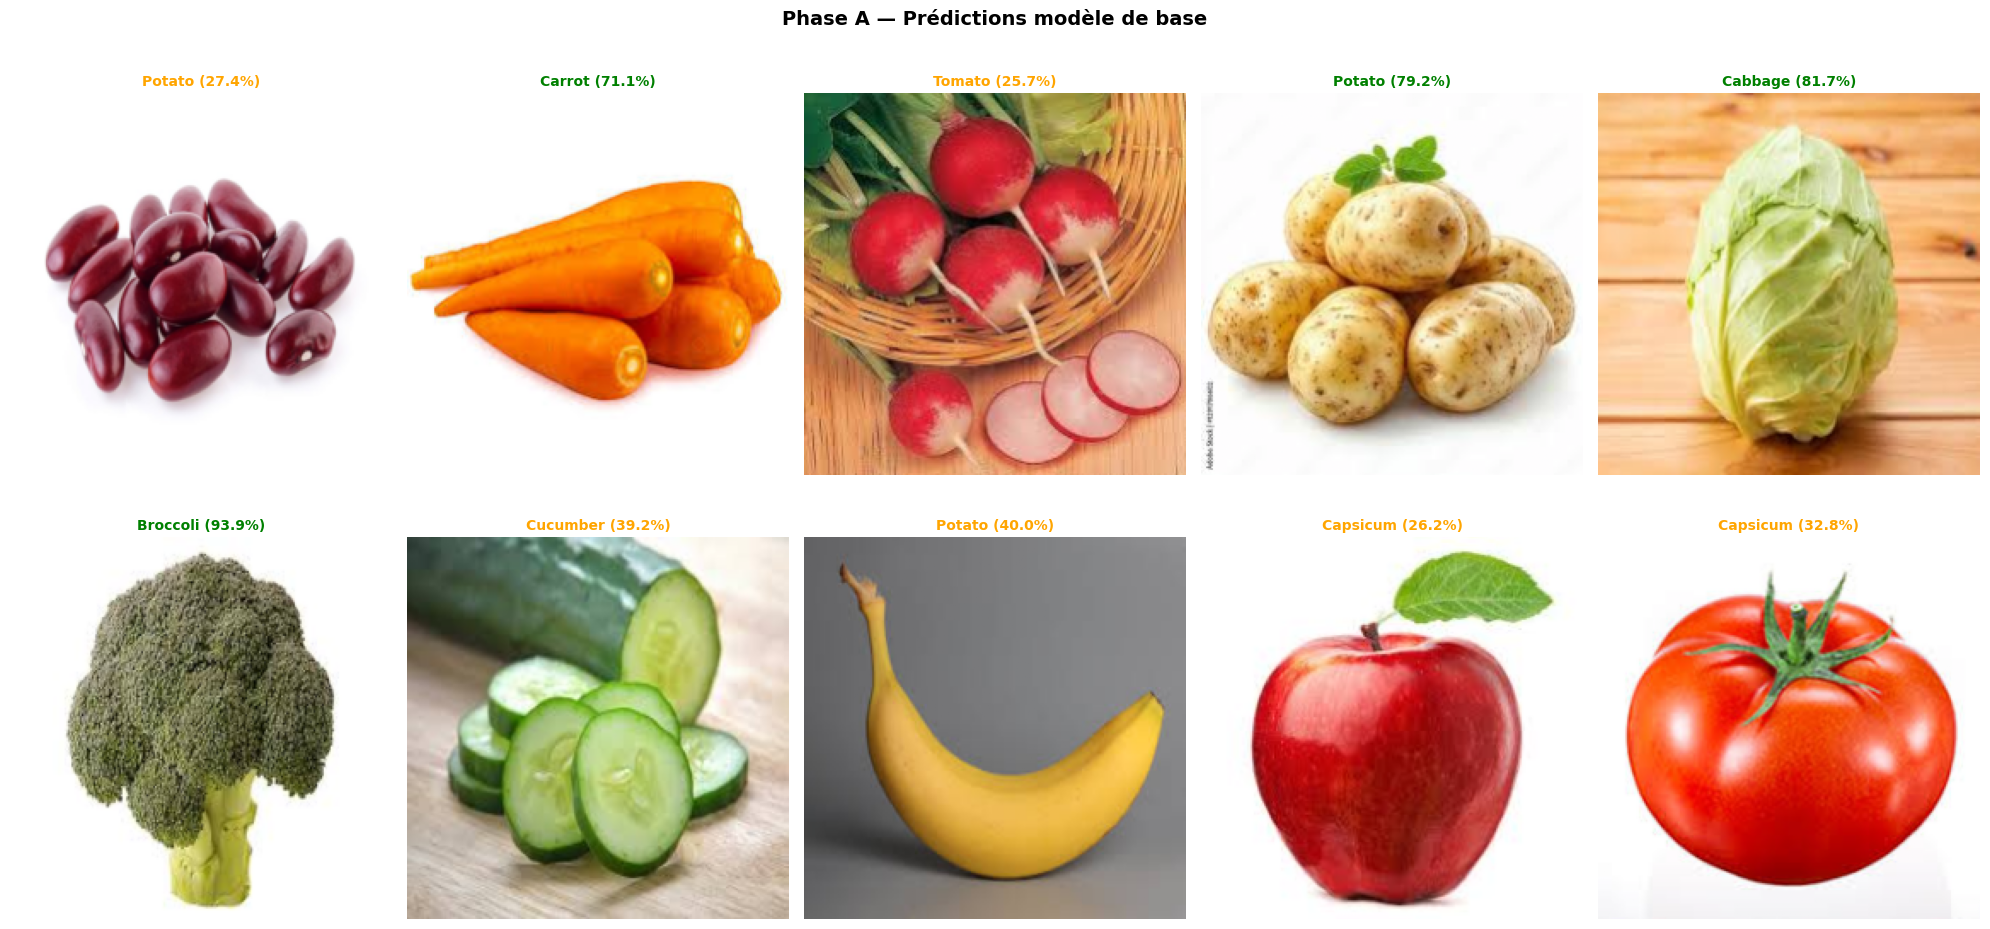

<Figure size 640x480 with 0 Axes>

In [16]:
# %% — A.5 : Prédictions sur notre dataset
print(f"\n── A.5 — Prédictions sur notre dataset ──")
my_paths = sorted([p for p in glob.glob(os.path.join(MY_IMAGES_DIR, "**/*.*"), recursive=True)
                   if p.lower().endswith(('.jpg','.jpeg','.png','.webp'))])

if len(my_paths) == 0:
    print("   Aucune image trouvée dans MY_IMAGES_DIR")
else:
    baseline.eval()
    ncols = min(len(my_paths), 5)
    nrows = max(1, (len(my_paths) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 5*nrows))
    axes = np.array(axes).flatten()

    print(f"\n{'#':<4} {'Fichier':<30} {'Prédiction':<20} {'Confiance':>10}")
    print("─" * 68)
    for i, path in enumerate(my_paths):
        tensor = eval_transform(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = F.softmax(baseline(tensor), dim=1)[0]
            conf, idx = probs.max(0)
        name = CLASS_NAMES[idx]; c = conf.item()*100
        print(f" {i+1:<3} {os.path.basename(path):<30} {name:<20} {c:>9.2f}%")
        axes[i].imshow(denorm(tensor)); axes[i].axis('off')
        axes[i].set_title(f"{name} ({c:.1f}%)", fontsize=10, fontweight='bold',
                          color='green' if c > 70 else 'orange')
    for j in range(len(my_paths), len(axes)): axes[j].axis('off')
    fig.suptitle("Phase A — Prédictions modèle de base", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, "A_predictions.png"), dpi=150, bbox_inches='tight')
    

## Metrics Visualization

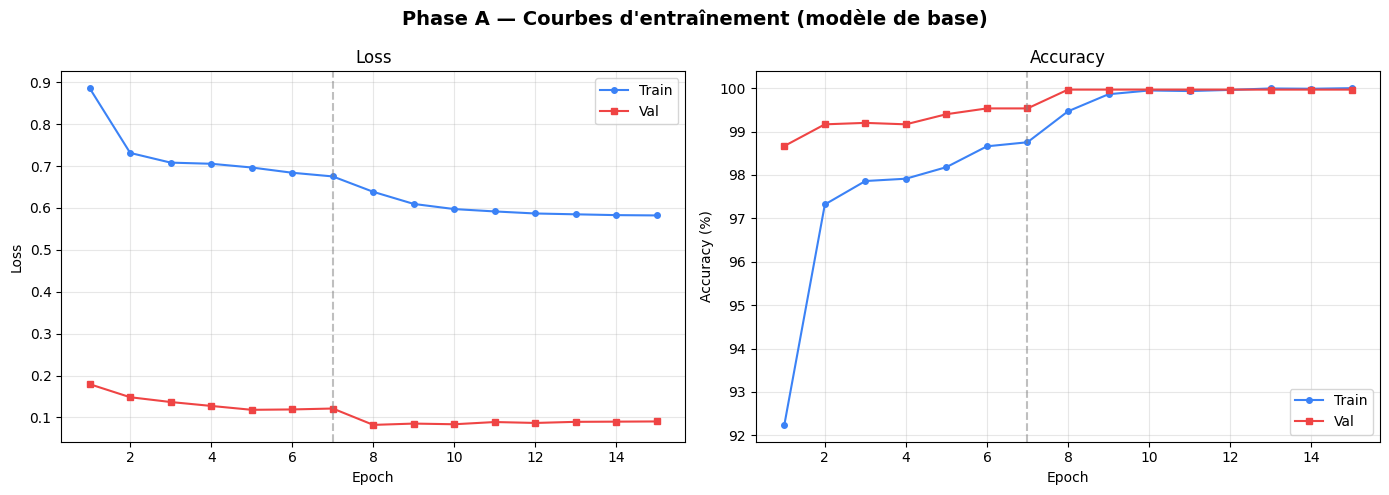

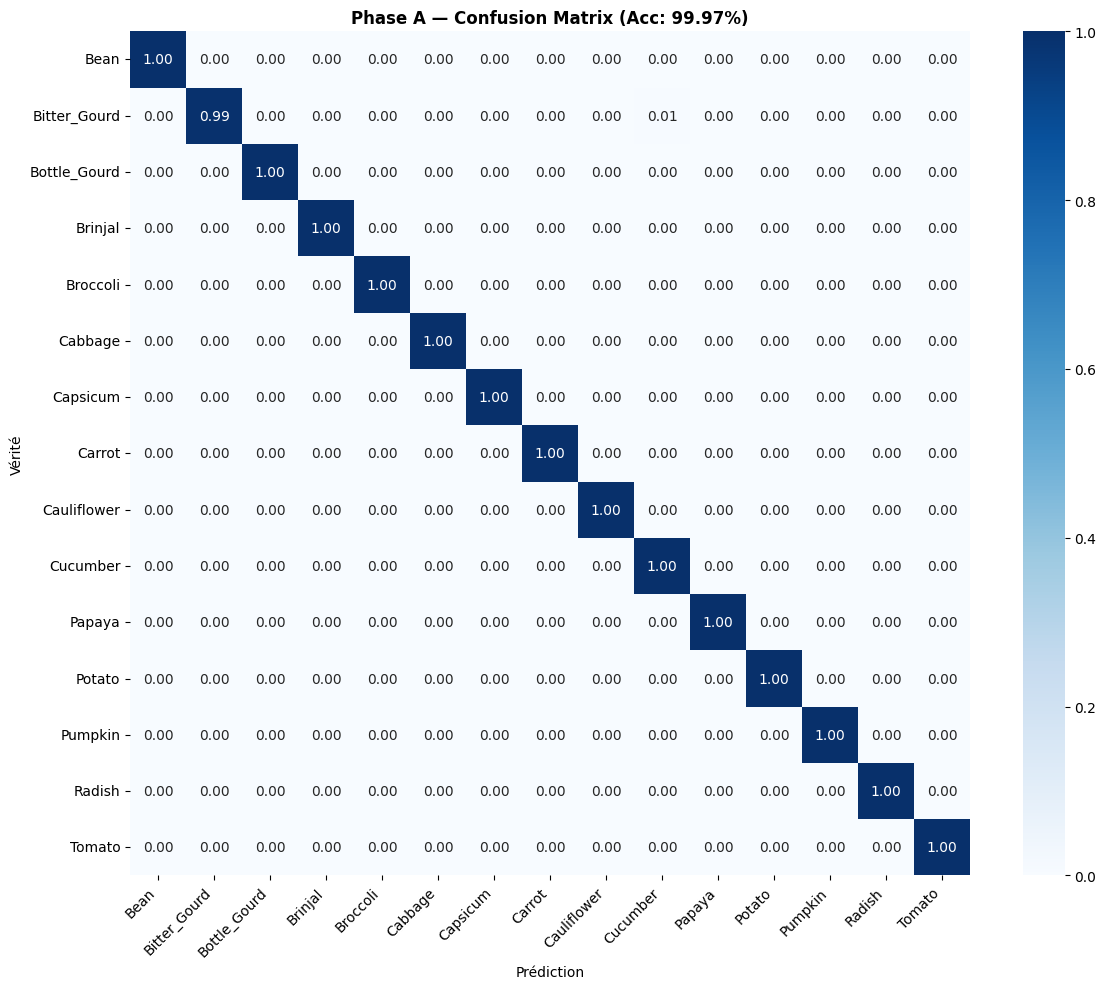

<Figure size 640x480 with 0 Axes>

In [18]:
# %% — A.6 : Courbes + confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase A — Courbes d'entraînement (modèle de base)", fontsize=14, fontweight='bold')
ep = range(1, len(hist_A["train_loss"])+1)
axes[0].plot(ep, hist_A["train_loss"], 'o-', color='#3b82f6', label='Train', ms=4)
axes[0].plot(ep, hist_A["val_loss"], 's-', color='#ef4444', label='Val', ms=4)
axes[0].axvline(x=P1, color='gray', ls='--', alpha=0.5); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[1].plot(ep, hist_A["train_acc"], 'o-', color='#3b82f6', label='Train', ms=4)
axes[1].plot(ep, hist_A["val_acc"], 's-', color='#ef4444', label='Val', ms=4)
axes[1].axvline(x=P1, color='gray', ls='--', alpha=0.5); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].set_title("Accuracy")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "A_training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

cm_A = confusion_matrix(res_A["labels"], res_A["preds"])
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_A.astype('float') / cm_A.sum(axis=1)[:, None], annot=True, fmt='.2f',
            cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f"Phase A — Confusion Matrix (Acc: {res_A['accuracy']:.2f}%)", fontweight='bold')
ax.set_xlabel("Prédiction"); ax.set_ylabel("Vérité")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right'); plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "A_confusion_matrix.png"), dpi=150, bbox_inches='tight')


# Adversarial Attacks

## FGSM

In [19]:
print("\n── B.1 — FGSM (Fast Gradient Sign Method) ──")
fgsm_results_A = []
for eps in FGSM_EPSILONS:
    r = evaluate_attack(baseline, test_loader, lambda m, x, y, e=eps: fgsm_attack(m, x, y, e))
    drop = res_A["accuracy"] - r["accuracy"]
    fgsm_results_A.append({"eps": eps, **r, "drop": drop})
    print(f"  ε={eps:.2f} → Acc: {r['accuracy']:.2f}% (↓{drop:.2f}%) | F1: {r['f1']:.4f}")


── B.1 — FGSM (Fast Gradient Sign Method) ──
  ε=0.01 → Acc: 82.40% (↓17.57%) | F1: 0.8208
  ε=0.03 → Acc: 54.33% (↓45.63%) | F1: 0.5396
  ε=0.05 → Acc: 48.87% (↓51.10%) | F1: 0.4863
  ε=0.10 → Acc: 48.90% (↓51.07%) | F1: 0.4842
  ε=0.15 → Acc: 53.40% (↓46.57%) | F1: 0.5240


## PGD

In [20]:
# %% — B.2 : PGD
print("\n── B.2 — PGD (Projected Gradient Descent) ──")
pgd_results_A = []
for eps in PGD_EPSILONS:
    r = evaluate_attack(baseline, test_loader,
                        lambda m, x, y, e=eps: pgd_attack(m, x, y, e, PGD_ALPHA, PGD_STEPS))
    drop = res_A["accuracy"] - r["accuracy"]
    pgd_results_A.append({"eps": eps, **r, "drop": drop})
    print(f"  ε={eps:.2f} → Acc: {r['accuracy']:.2f}% (↓{drop:.2f}%) | F1: {r['f1']:.4f}")



── B.2 — PGD (Projected Gradient Descent) ──
  ε=0.01 → Acc: 20.40% (↓79.57%) | F1: 0.2090
  ε=0.03 → Acc: 0.00% (↓99.97%) | F1: 0.0000
  ε=0.05 → Acc: 0.00% (↓99.97%) | F1: 0.0000
  ε=0.10 → Acc: 0.00% (↓99.97%) | F1: 0.0000


## Data Poisoning

In [23]:
# %% — B.3 : Data Poisoning
print("\n── B.3 — Data Poisoning (Label Flipping) ──")
train_raw = ImageFolder(os.path.join(DATA_DIR, "train"), transform=eval_transform)
poison_results = []

for pf in POISON_FRACS:
    n = len(train_raw); n_p = int(n * pf)
    idx_p = random.sample(range(n), n_p)

    poisoned = copy.copy(train_raw)
    poisoned.samples = list(train_raw.samples)
    for i in idx_p:
        path, orig = poisoned.samples[i]
        poisoned.samples[i] = (path, random.choice([c for c in range(NUM_CLASSES) if c != orig]))
    poisoned.targets = [s[1] for s in poisoned.samples]

    p_loader = DataLoader(poisoned, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    p_model = build_model()
    p_opt = optim.Adam(p_model.parameters(), lr=LR_FROZEN)
    p_model.train()
    for _ in range(3):
        for imgs, lbls in p_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            p_opt.zero_grad(); F.cross_entropy(p_model(imgs), lbls).backward(); p_opt.step()
    r = evaluate_clean(p_model, test_loader)
    poison_results.append({"frac": pf, "accuracy": r["accuracy"], "f1": r["f1"]})
    print(f"  {pf*100:.0f}% empoisonné → Acc: {r['accuracy']:.2f}% | F1: {r['f1']:.4f}")
    del p_model; torch.cuda.empty_cache() if torch.cuda.is_available() else None


── B.3 — Data Poisoning (Label Flipping) ──
  5% empoisonné → Acc: 99.17% | F1: 0.9917
  10% empoisonné → Acc: 96.63% | F1: 0.9662
  20% empoisonné → Acc: 99.50% | F1: 0.9950
  30% empoisonné → Acc: 98.60% | F1: 0.9860



── B.4 — Exemples adversariaux visuels ──


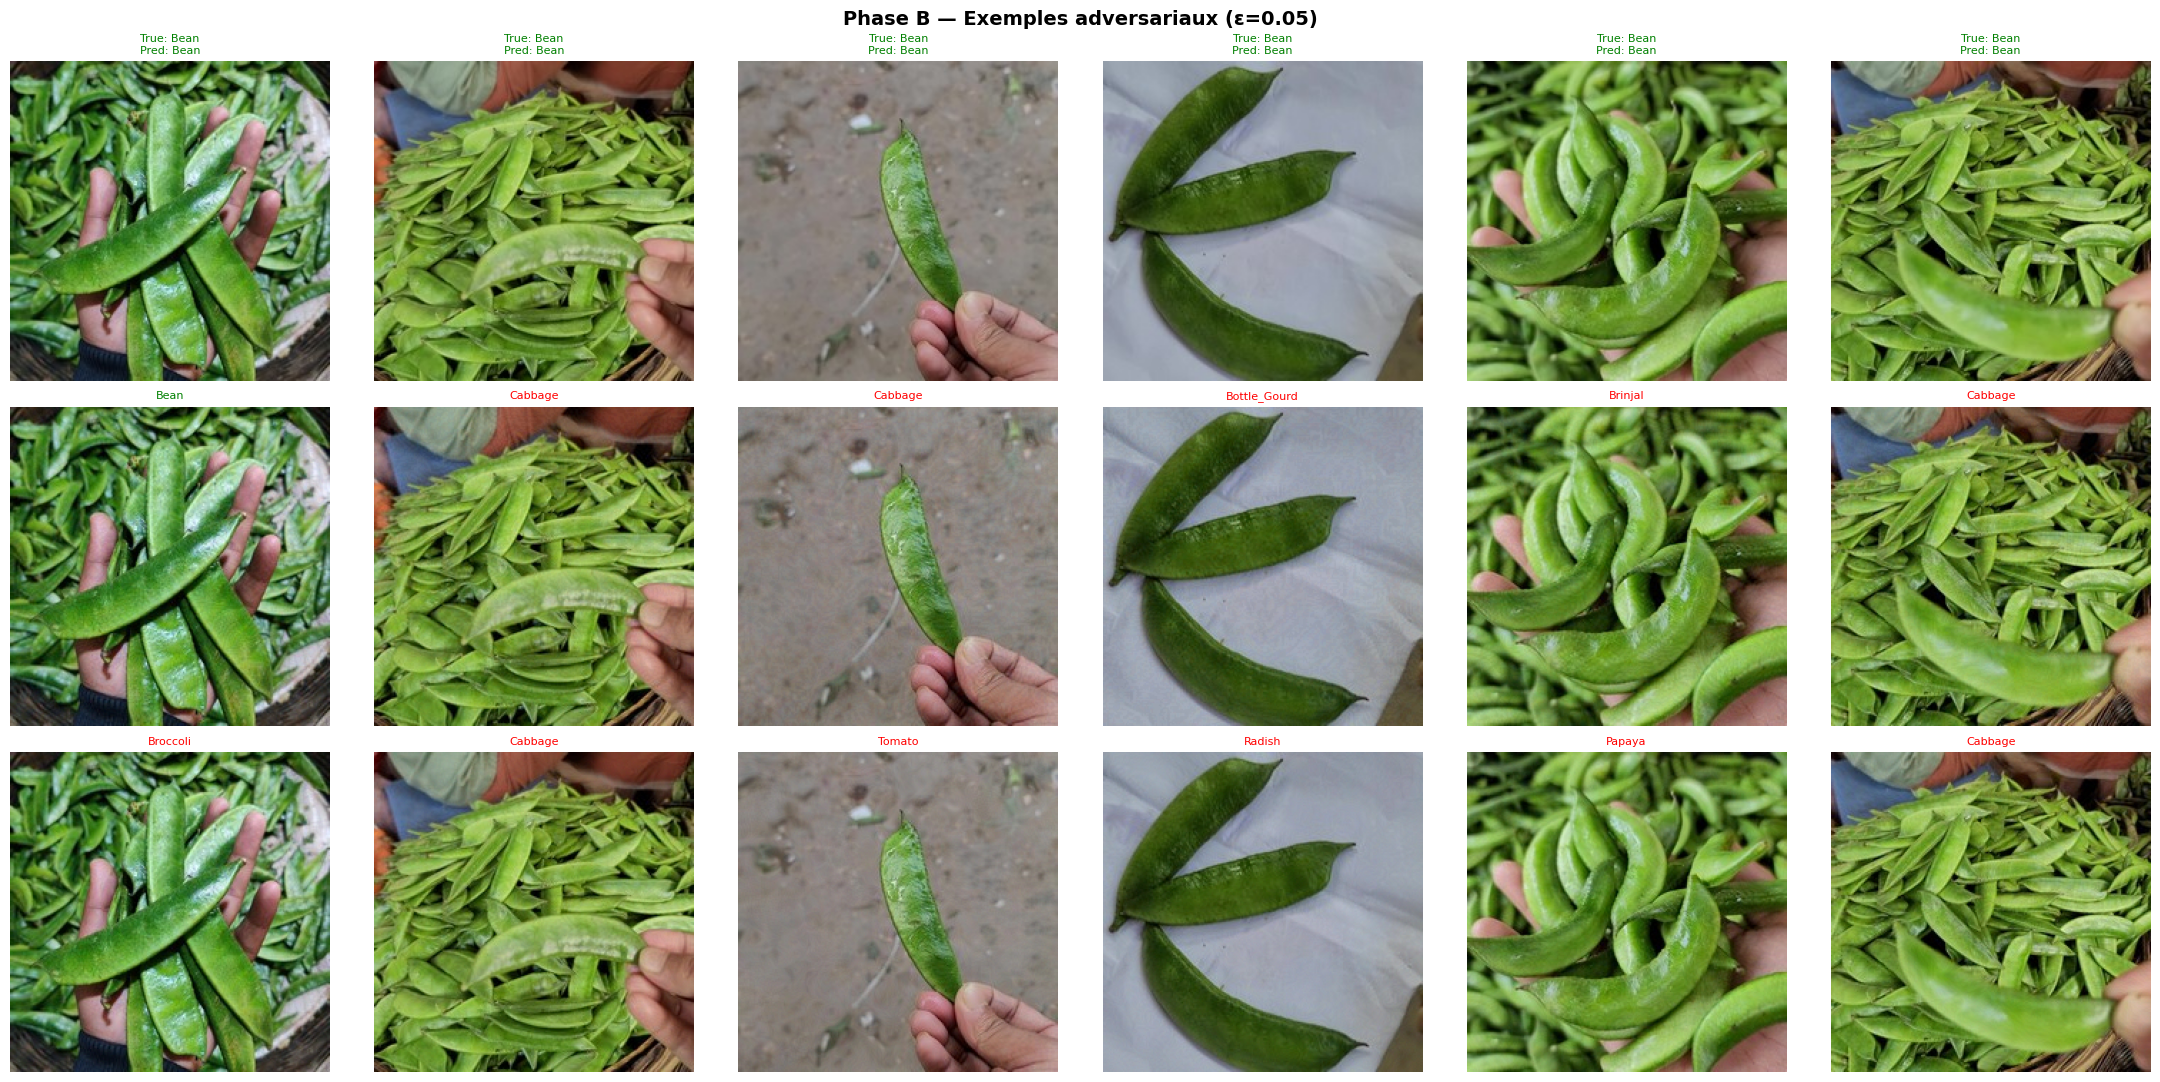

<Figure size 640x480 with 0 Axes>

In [24]:
print("\n── B.4 — Exemples adversariaux visuels ──")
baseline.eval()
s_imgs, s_lbls = next(iter(test_loader))
s_imgs, s_lbls = s_imgs[:6].to(DEVICE), s_lbls[:6].to(DEVICE)

adv_fgsm = fgsm_attack(baseline, s_imgs, s_lbls, 0.05)
adv_pgd  = pgd_attack(baseline, s_imgs, s_lbls, 0.05, PGD_ALPHA, PGD_STEPS)

with torch.no_grad():
    p_clean = baseline(s_imgs).argmax(1)
    p_fgsm  = baseline(adv_fgsm).argmax(1)
    p_pgd   = baseline(adv_pgd).argmax(1)

fig, axes = plt.subplots(3, 6, figsize=(22, 11))
fig.suptitle("Phase B — Exemples adversariaux (ε=0.05)", fontsize=14, fontweight='bold')
for i in range(6):
    for row, (tensor, pred, label) in enumerate([
        (s_imgs[i], p_clean[i], "Original"),
        (adv_fgsm[i], p_fgsm[i], "FGSM"),
        (adv_pgd[i], p_pgd[i], "PGD"),
    ]):
        axes[row, i].imshow(denorm(tensor.unsqueeze(0)))
        ok = pred == s_lbls[i]
        title = f"{CLASS_NAMES[pred]}" if row > 0 else f"True: {CLASS_NAMES[s_lbls[i]]}\nPred: {CLASS_NAMES[pred]}"
        axes[row, i].set_title(title, fontsize=8, color='green' if ok else 'red')
        axes[row, i].axis('off')
for ax, lbl in zip(axes[:, 0], ["Original", "FGSM ε=0.05", "PGD ε=0.05"]):
    ax.set_ylabel(lbl, fontsize=11, fontweight='bold', rotation=0, labelpad=70, va='center')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "B_adversarial_examples.png"), dpi=150, bbox_inches='tight')


## Performance Visualization

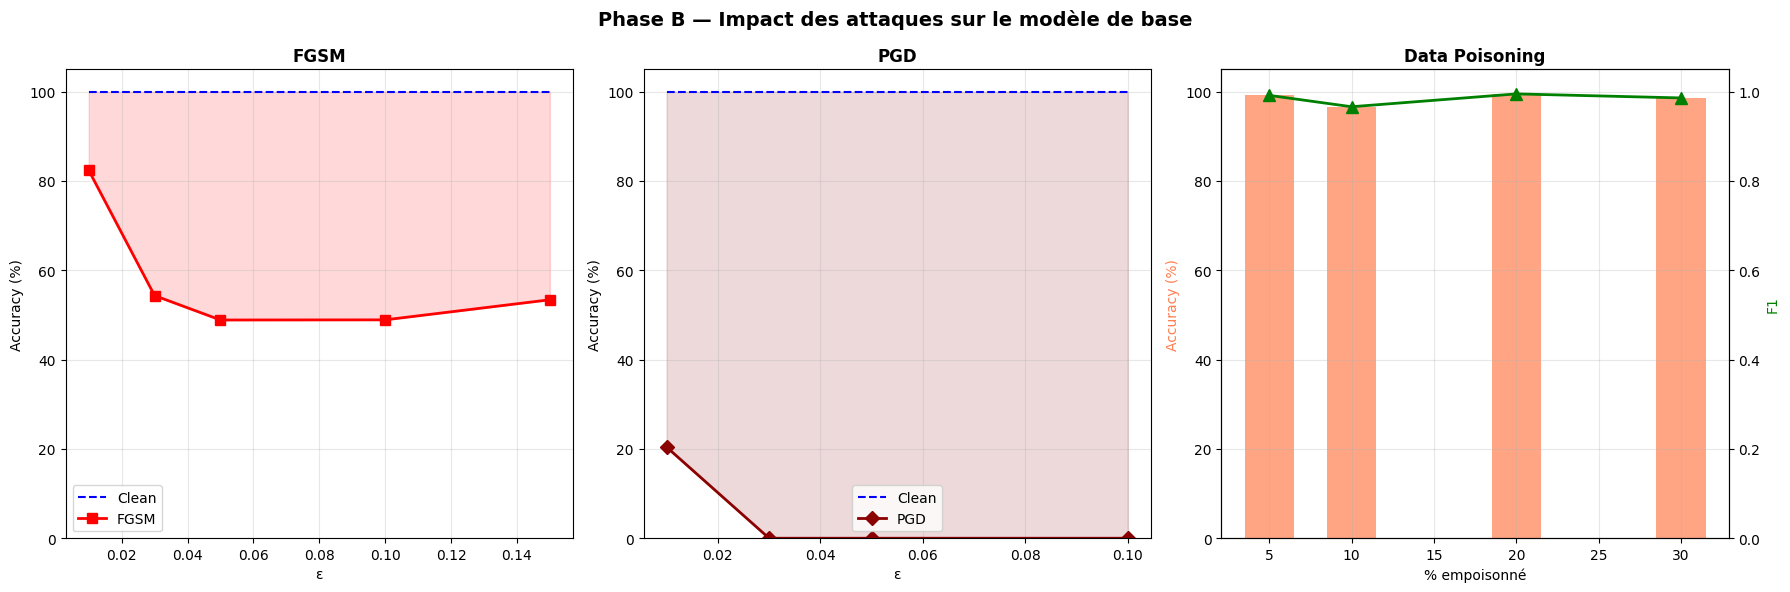

<Figure size 640x480 with 0 Axes>

In [25]:
# %% — B.5 : Graphiques d'impact
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Phase B — Impact des attaques sur le modèle de base", fontsize=14, fontweight='bold')

axes[0].plot(FGSM_EPSILONS, [res_A["accuracy"]]*len(FGSM_EPSILONS), 'b--', lw=1.5, label='Clean')
axes[0].plot(FGSM_EPSILONS, [r["accuracy"] for r in fgsm_results_A], 'r-s', lw=2, ms=7, label='FGSM')
axes[0].fill_between(FGSM_EPSILONS, [r["accuracy"] for r in fgsm_results_A],
                     res_A["accuracy"], alpha=0.15, color='red')
axes[0].set_title("FGSM", fontweight='bold'); axes[0].set_xlabel("ε")
axes[0].set_ylabel("Accuracy (%)"); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 105)

axes[1].plot(PGD_EPSILONS, [res_A["accuracy"]]*len(PGD_EPSILONS), 'b--', lw=1.5, label='Clean')
axes[1].plot(PGD_EPSILONS, [r["accuracy"] for r in pgd_results_A], 'darkred', marker='D', lw=2, ms=7, label='PGD')
axes[1].fill_between(PGD_EPSILONS, [r["accuracy"] for r in pgd_results_A],
                     res_A["accuracy"], alpha=0.15, color='darkred')
axes[1].set_title("PGD", fontweight='bold'); axes[1].set_xlabel("ε")
axes[1].set_ylabel("Accuracy (%)"); axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 105)

fracs = [r["frac"]*100 for r in poison_results]
ax2 = axes[2].twinx()
axes[2].bar(fracs, [r["accuracy"] for r in poison_results], width=3, color='coral', alpha=0.7)
ax2.plot(fracs, [r["f1"] for r in poison_results], 'g-^', lw=2, ms=8)
axes[2].set_title("Data Poisoning", fontweight='bold'); axes[2].set_xlabel("% empoisonné")
axes[2].set_ylabel("Accuracy (%)", color='coral'); ax2.set_ylabel("F1", color='green')
axes[2].set_ylim(0, 105); ax2.set_ylim(0, 1.05); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "B_attack_impact.png"), dpi=150, bbox_inches='tight')


# Hardened Model

## Adversarial Training

In [26]:
# ## PHASE C — Durcissement par adversarial training + vérification

# %% — C.1 : Adversarial training PGD
print(" PHASE C : DURCISSEMENT (ADVERSARIAL TRAINING PGD)")

hardened = build_model()
hardened.load_state_dict(baseline.state_dict())  # partir du modèle de base
criterion_C = nn.CrossEntropyLoss(label_smoothing=0.1)
opt_C = optim.Adam(hardened.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY)
sched_C = optim.lr_scheduler.CosineAnnealingLR(opt_C, T_max=EPOCHS_HARDEN)

hist_C = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_C = 0.0

print(f"\n  Config: ε={ADV_EPSILON}, α={ADV_ALPHA}, steps={ADV_STEPS}, ratio={ADV_RATIO}")
print(f"  Epochs: {EPOCHS_HARDEN}\n")

for epoch in range(1, EPOCHS_HARDEN + 1):
    t0 = time.time()
    hardened.train()
    rloss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        bs = imgs.size(0); n_adv = int(bs * ADV_RATIO)

        hardened.eval()
        adv = pgd_attack(hardened, imgs[:n_adv], lbls[:n_adv], ADV_EPSILON, ADV_ALPHA, ADV_STEPS)
        hardened.train()

        combined = torch.cat([adv, imgs[n_adv:]])
        combined_lbls = torch.cat([lbls[:n_adv], lbls[n_adv:]])

        opt_C.zero_grad()
        out = hardened(combined); loss = criterion_C(out, combined_lbls)
        loss.backward(); opt_C.step()
        rloss += loss.item() * combined.size(0)
        correct += out.argmax(1).eq(combined_lbls).sum().item(); total += combined_lbls.size(0)
    sched_C.step()
    tl, ta = rloss/total, 100.*correct/total

    res_val = evaluate_clean(hardened, val_loader)
    vl, va = res_val["loss"], res_val["accuracy"]
    hist_C["train_loss"].append(tl); hist_C["train_acc"].append(ta)
    hist_C["val_loss"].append(vl);   hist_C["val_acc"].append(va)

    print(f"  Epoch [{epoch}/{EPOCHS_HARDEN}] "
          f"Train: {tl:.4f}/{ta:.2f}% | Val: {vl:.4f}/{va:.2f}% | {time.time()-t0:.1f}s")
    if va > best_val_acc_C:
        best_val_acc_C = va
        torch.save(hardened.state_dict(), os.path.join(OUTPUT_DIR, "_best_C.pth"))

hardened.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "_best_C.pth"), weights_only=True))

 PHASE C : DURCISSEMENT (ADVERSARIAL TRAINING PGD)

  Config: ε=0.03, α=0.007, steps=7, ratio=0.5
  Epochs: 10

  Epoch [1/10] Train: 1.2473/78.84% | Val: 0.0403/99.80% | 320.7s
  Epoch [2/10] Train: 0.7307/95.20% | Val: 0.0457/99.90% | 325.8s
  Epoch [3/10] Train: 0.6630/97.80% | Val: 0.0487/99.93% | 326.0s
  Epoch [4/10] Train: 0.6389/98.54% | Val: 0.0548/99.97% | 326.2s
  Epoch [5/10] Train: 0.6263/98.93% | Val: 0.0586/99.97% | 326.3s
  Epoch [6/10] Train: 0.6142/99.29% | Val: 0.0629/99.97% | 326.5s
  Epoch [7/10] Train: 0.6086/99.43% | Val: 0.0643/99.97% | 328.0s
  Epoch [8/10] Train: 0.6046/99.55% | Val: 0.0642/99.97% | 328.6s
  Epoch [9/10] Train: 0.5998/99.71% | Val: 0.0644/99.97% | 328.9s
  Epoch [10/10] Train: 0.5995/99.69% | Val: 0.0663/99.97% | 328.5s


<All keys matched successfully>

## Evaluation

In [27]:
# %% — C.2 : Évaluation clean du modèle durci
print(f"\n── C.2 — Évaluation clean du modèle durci ──")
res_C = evaluate_clean(hardened, test_loader)
print(f"  Accuracy:  {res_C['accuracy']:.2f}%  (base: {res_A['accuracy']:.2f}%)")
print(f"  F1-Score:  {res_C['f1']:.4f}  (base: {res_A['f1']:.4f})")
print(f"\n{classification_report(res_C['labels'], res_C['preds'], target_names=CLASS_NAMES)}")


── C.2 — Évaluation clean du modèle durci ──
  Accuracy:  99.93%  (base: 99.97%)
  F1-Score:  0.9993  (base: 0.9997)

              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      1.00       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      0.99      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       200

    accuracy   

## Attacks Performing

In [28]:
# %% — C.3 : Mêmes attaques sur le modèle durci
print(f"\n── C.3 — Mêmes attaques FGSM/PGD sur le modèle durci ──")

print("\n  FGSM :")
fgsm_results_C = []
for eps in FGSM_EPSILONS:
    r = evaluate_attack(hardened, test_loader, lambda m, x, y, e=eps: fgsm_attack(m, x, y, e))
    fgsm_results_C.append({"eps": eps, **r})
    base_r = next(x for x in fgsm_results_A if x["eps"] == eps)
    print(f"    ε={eps:.2f} → Acc: {r['accuracy']:.2f}%  (base: {base_r['accuracy']:.2f}%, Δ+{r['accuracy']-base_r['accuracy']:.2f}%)")

print("\n  PGD :")
pgd_results_C = []
for eps in PGD_EPSILONS:
    r = evaluate_attack(hardened, test_loader,
                        lambda m, x, y, e=eps: pgd_attack(m, x, y, e, PGD_ALPHA, PGD_STEPS))
    pgd_results_C.append({"eps": eps, **r})
    base_r = next(x for x in pgd_results_A if x["eps"] == eps)
    print(f"    ε={eps:.2f} → Acc: {r['accuracy']:.2f}%  (base: {base_r['accuracy']:.2f}%, Δ+{r['accuracy']-base_r['accuracy']:.2f}%)")


── C.3 — Mêmes attaques FGSM/PGD sur le modèle durci ──

  FGSM :
    ε=0.01 → Acc: 99.80%  (base: 82.40%, Δ+17.40%)
    ε=0.03 → Acc: 99.37%  (base: 54.33%, Δ+45.03%)
    ε=0.05 → Acc: 98.50%  (base: 48.87%, Δ+49.63%)
    ε=0.10 → Acc: 95.73%  (base: 48.90%, Δ+46.83%)
    ε=0.15 → Acc: 93.37%  (base: 53.40%, Δ+39.97%)

  PGD :
    ε=0.01 → Acc: 99.80%  (base: 20.40%, Δ+79.40%)
    ε=0.03 → Acc: 98.83%  (base: 0.00%, Δ+98.83%)
    ε=0.05 → Acc: 96.60%  (base: 0.00%, Δ+96.60%)
    ε=0.10 → Acc: 93.03%  (base: 0.00%, Δ+93.03%)


## Exportation

In [29]:
# %% — C.4 : Sauvegarde modèle durci
save_C = os.path.join(OUTPUT_DIR, "hardened_model.pth")
torch.save({
    "model_state_dict": hardened.state_dict(),
    "architecture": "efficientnet_b0",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "test_acc": res_C["accuracy"],
    "test_f1": res_C["f1"],
    "training": "adversarial_pgd",
    "adv_config": {"epsilon": ADV_EPSILON, "alpha": ADV_ALPHA, "steps": ADV_STEPS, "ratio": ADV_RATIO},
}, save_C)
print(f"\n Modèle durci sauvegardé: {save_C}")


 Modèle durci sauvegardé: /kaggle/working/hardened_model.pth


## Comparison

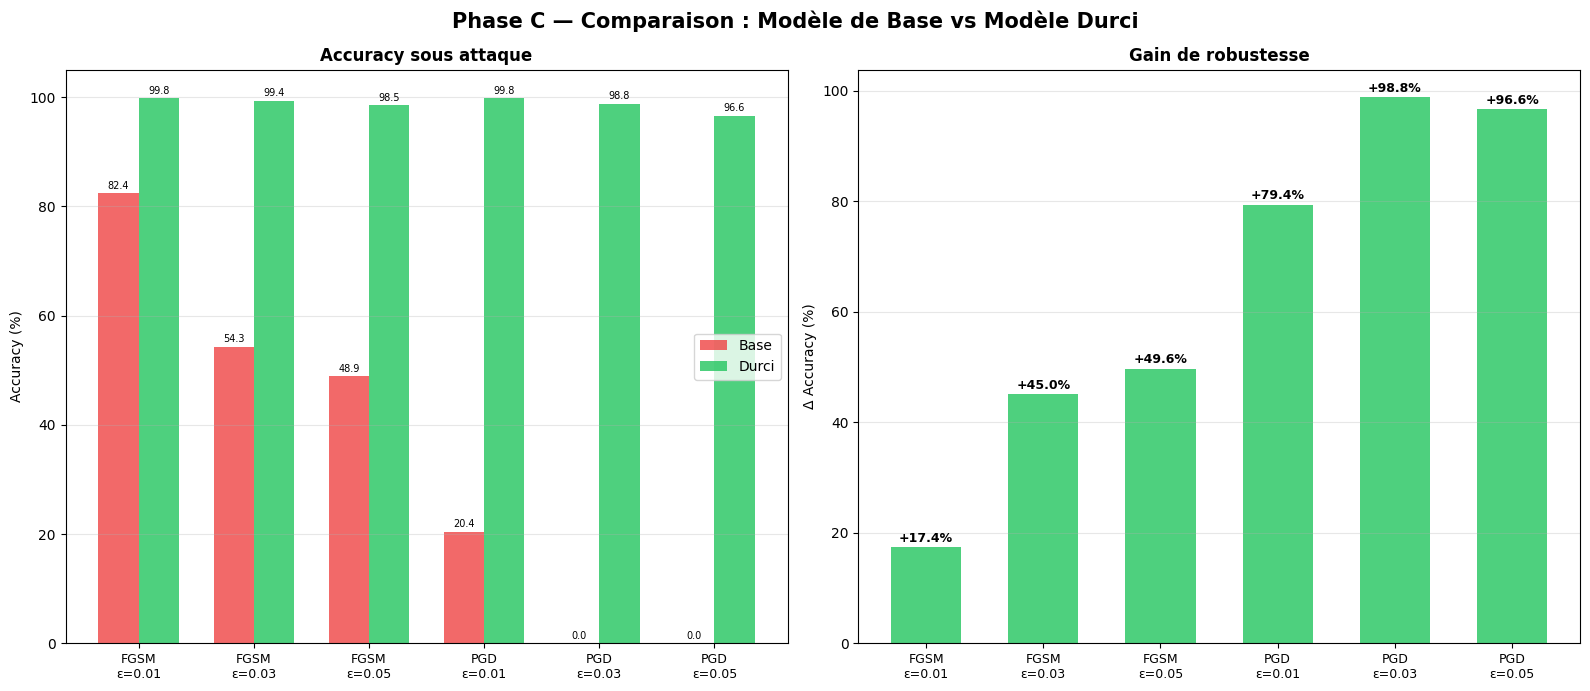

<Figure size 640x480 with 0 Axes>

In [30]:
# %% — C.5 : Comparaison graphique avant/après
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Phase C — Comparaison : Modèle de Base vs Modèle Durci", fontsize=15, fontweight='bold')

attacks = ([f"FGSM\nε={r['eps']}" for r in fgsm_results_A[:3]]
         + [f"PGD\nε={r['eps']}" for r in pgd_results_A[:3]])
base_accs = ([r["accuracy"] for r in fgsm_results_A[:3]]
           + [r["accuracy"] for r in pgd_results_A[:3]])
hard_accs = ([r["accuracy"] for r in fgsm_results_C[:3]]
           + [r["accuracy"] for r in pgd_results_C[:3]])

x = np.arange(len(attacks)); w = 0.35
b1 = axes[0].bar(x - w/2, base_accs, w, label='Base', color='#ef4444', alpha=0.8)
b2 = axes[0].bar(x + w/2, hard_accs, w, label='Durci', color='#22c55e', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(attacks, fontsize=9)
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_ylim(0, 105)
axes[0].set_title("Accuracy sous attaque", fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{bar.get_height():.1f}',
                 ha='center', fontsize=7)
for bar in b2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8, f'{bar.get_height():.1f}',
                 ha='center', fontsize=7)

gains = [h - b for b, h in zip(base_accs, hard_accs)]
colors = ['#22c55e' if g > 0 else '#ef4444' for g in gains]
axes[1].bar(x, gains, 0.6, color=colors, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(attacks, fontsize=9)
axes[1].set_ylabel("Δ Accuracy (%)"); axes[1].set_title("Gain de robustesse", fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for xi, g in zip(x, gains):
    axes[1].text(xi, g + (1 if g >= 0 else -2), f'{g:+.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "C_robustness_comparison.png"), dpi=150, bbox_inches='tight')


# Prediction

In [31]:
# %% — C.6 : Prédictions comparées sur notre dataset
if len(my_paths) > 0:
    print(f"\n── C.6 — Prédictions comparées (base vs durci) sur notre dataset ──")
    baseline.eval(); hardened.eval()

    print(f"\n{'#':<4} {'Fichier':<25} {'Base':<22} {'Durci':<22}")
    print("─" * 75)
    for i, path in enumerate(my_paths):
        tensor = eval_transform(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pb = F.softmax(baseline(tensor), dim=1)[0]
            ph = F.softmax(hardened(tensor), dim=1)[0]
        cb, ib = pb.max(0); ch, ih = ph.max(0)
        print(f" {i+1:<3} {os.path.basename(path):<25} "
              f"{CLASS_NAMES[ib]} ({cb.item()*100:.1f}%)   "
              f"{CLASS_NAMES[ih]} ({ch.item()*100:.1f}%)")


── C.6 — Prédictions comparées (base vs durci) sur notre dataset ──

#    Fichier                   Base                   Durci                 
───────────────────────────────────────────────────────────────────────────
 1   Kidney-beans-8496667.jpg  Potato (27.4%)   Potato (33.5%)
 2   images (1).jpeg           Carrot (71.1%)   Carrot (61.1%)
 3   images (2).jpeg           Tomato (25.7%)   Tomato (42.9%)
 4   images (3).jpeg           Potato (79.2%)   Potato (56.1%)
 5   images (4).jpeg           Cabbage (81.7%)   Cabbage (85.5%)
 6   images (5).jpeg           Broccoli (93.9%)   Broccoli (95.8%)
 7   images (6).jpeg           Cucumber (39.2%)   Papaya (29.8%)
 8   images (7).jpeg           Potato (40.0%)   Carrot (32.3%)
 9   images (8).jpeg           Capsicum (26.2%)   Capsicum (70.1%)
 10  images.jpeg               Capsicum (32.8%)   Capsicum (92.9%)


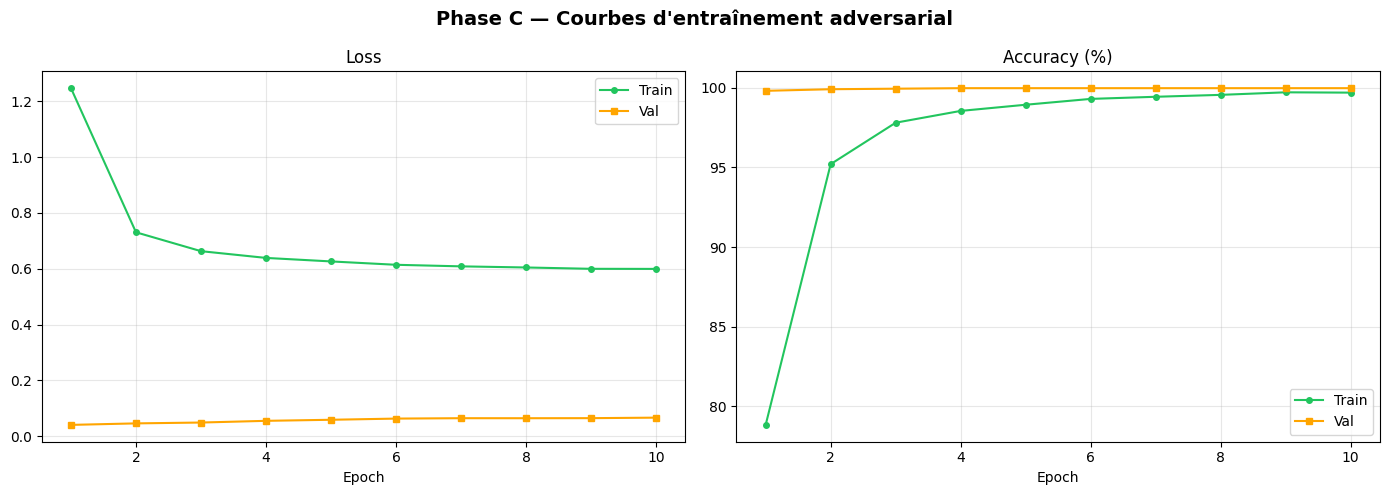

<Figure size 640x480 with 0 Axes>

In [32]:
# %% — C.7 : Courbes d'entraînement du durcissement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase C — Courbes d'entraînement adversarial", fontsize=14, fontweight='bold')
ep = range(1, len(hist_C["train_loss"])+1)
axes[0].plot(ep, hist_C["train_loss"], 'o-', color='#22c55e', label='Train', ms=4)
axes[0].plot(ep, hist_C["val_loss"], 's-', color='orange', label='Val', ms=4)
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[1].plot(ep, hist_C["train_acc"], 'o-', color='#22c55e', label='Train', ms=4)
axes[1].plot(ep, hist_C["val_acc"], 's-', color='orange', label='Val', ms=4)
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "C_training_curves.png"), dpi=150, bbox_inches='tight')


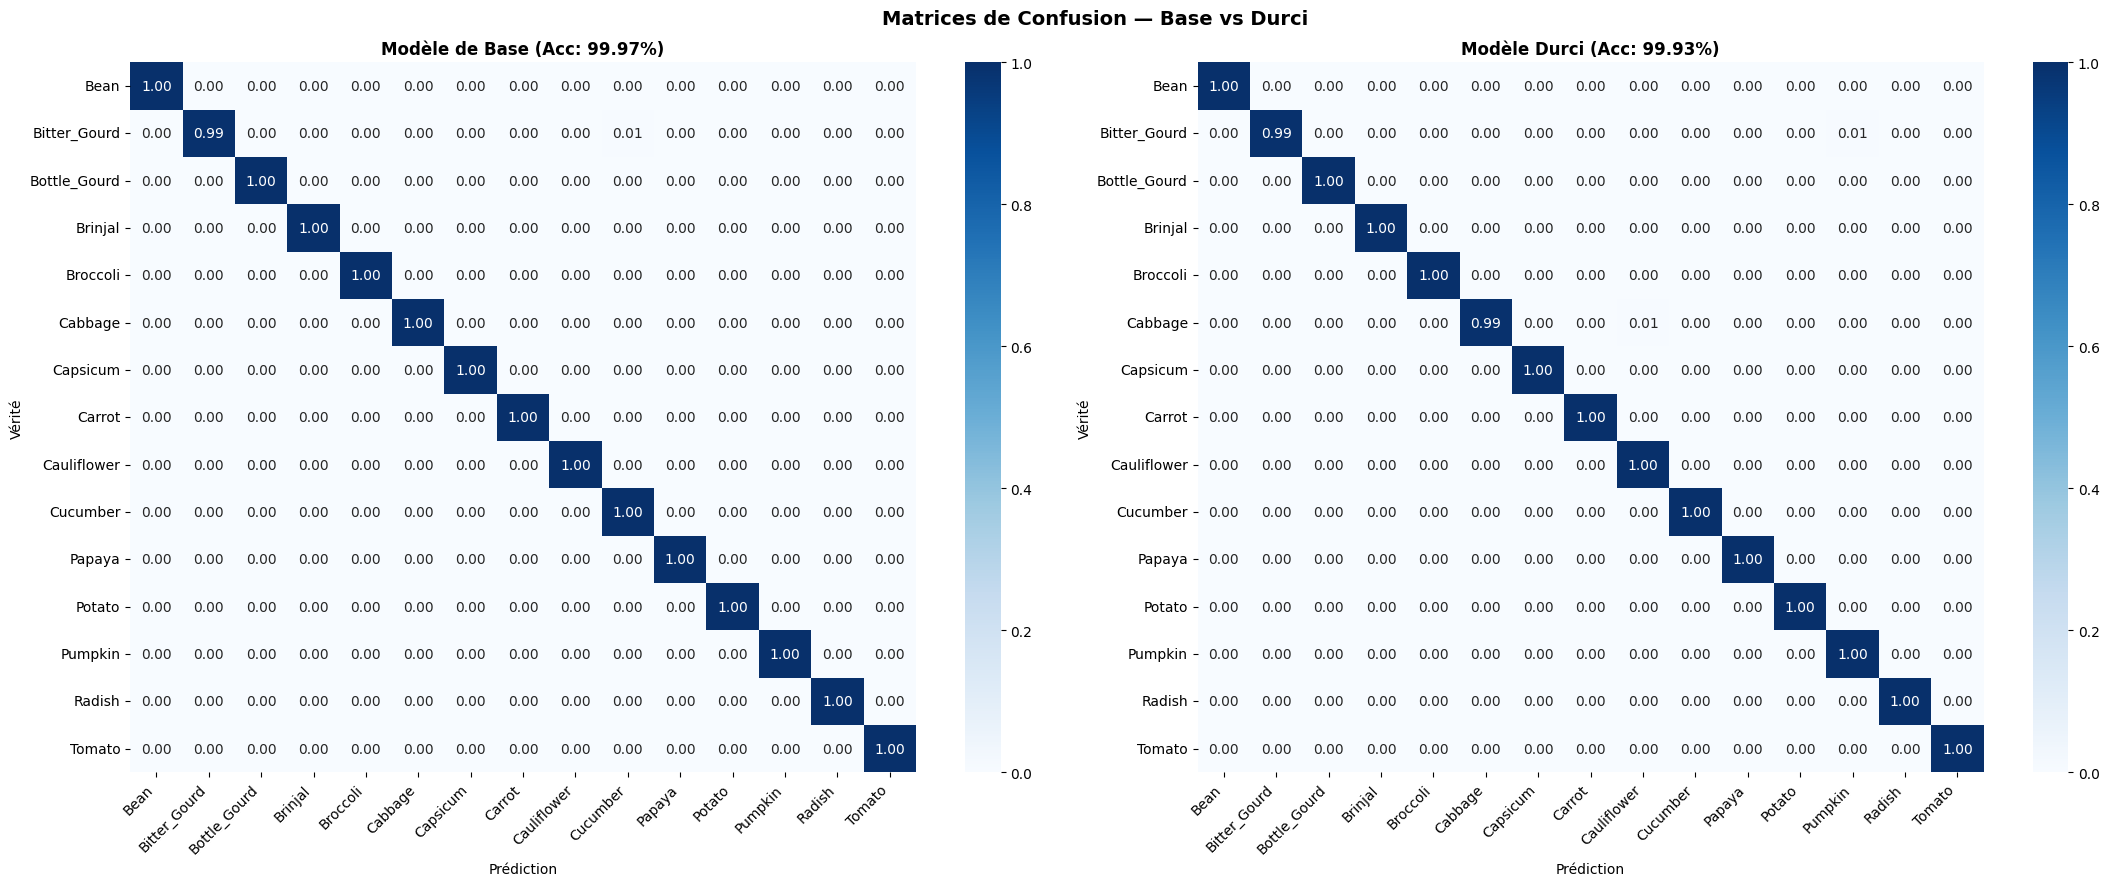

<Figure size 640x480 with 0 Axes>

In [33]:
# %% — C.8 : Confusion matrix du modèle durci
cm_C = confusion_matrix(res_C["labels"], res_C["preds"])
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle("Matrices de Confusion — Base vs Durci", fontsize=14, fontweight='bold')
for ax, cm, title, acc in [
    (axes[0], cm_A, "Modèle de Base", res_A["accuracy"]),
    (axes[1], cm_C, "Modèle Durci", res_C["accuracy"]),
]:
    sns.heatmap(cm.astype('float') / cm.sum(axis=1)[:, None], annot=True, fmt='.2f',
                cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{title} (Acc: {acc:.2f}%)", fontweight='bold')
    ax.set_xlabel("Prédiction"); ax.set_ylabel("Vérité")
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, "C_confusion_comparison.png"), dpi=150, bbox_inches='tight')
